## ANÁLISIS MULTIVARIANTE: CORRELACIÓN
CESNET TIME SERIES 24 - AGGREGATION 10 MINUTE
- Sacar TOP 5 CORRELACIONES
- Análisis de esos pares con ventanas deslizantes y umbrales para detectar comportamientos anómalos

In [2]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )


import pywt

def compute_optimal_window(signal, wavelet='db4', max_level=6):
    coeffs = pywt.wavedec(signal, wavelet, level=max_level)

    # coeffs = [A_j, D_j, D_{j-1}, ..., D1]
    energies = []

    for i in range(1, len(coeffs)):  # solo detalles
        Dj = coeffs[i]
        energy = np.sum(Dj**2)
        energies.append(energy)

    energies = np.array(energies)

    # Normalizar energías
    energies_norm = energies / np.sum(energies)

    # Buscar el "corte": donde la energía deja de ser relevante
    threshold = np.mean(energies_norm)
    significant_levels = np.where(energies_norm > threshold)[0]

    if len(significant_levels) == 0:
        j_opt = 1
    else:
        j_opt = significant_levels[-1] + 1  # +1 porque empezamos en D1

    window_size = 2 ** j_opt

    return window_size, energies_norm


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [3]:
# VARIABLES PARA USAR
file_path = os.path.join(agg_10_minutes_path, os.listdir(agg_10_minutes_path)[0])
df_TS24 = pd.read_csv(file_path)
print(df_TS24.columns[1:].tolist())


['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


In [4]:
# INSITUCIONES DISPONIBLES
csv_files = [
    f for f in os.listdir(agg_10_minutes_path)
    if f.endswith(".csv")
]

print(csv_files)



['0.csv', '1.csv', '10.csv', '100.csv', '101.csv', '102.csv', '103.csv', '104.csv', '105.csv', '106.csv', '107.csv', '108.csv', '109.csv', '11.csv', '110.csv', '111.csv', '112.csv', '113.csv', '114.csv', '115.csv', '116.csv', '117.csv', '118.csv', '119.csv', '12.csv', '120.csv', '121.csv', '122.csv', '123.csv', '124.csv', '125.csv', '126.csv', '127.csv', '128.csv', '129.csv', '13.csv', '130.csv', '131.csv', '132.csv', '133.csv', '134.csv', '135.csv', '136.csv', '137.csv', '138.csv', '139.csv', '14.csv', '140.csv', '141.csv', '142.csv', '143.csv', '144.csv', '145.csv', '146.csv', '147.csv', '148.csv', '149.csv', '15.csv', '150.csv', '151.csv', '152.csv', '153.csv', '154.csv', '155.csv', '156.csv', '157.csv', '158.csv', '159.csv', '16.csv', '160.csv', '161.csv', '162.csv', '163.csv', '164.csv', '165.csv', '166.csv', '167.csv', '168.csv', '169.csv', '17.csv', '170.csv', '171.csv', '172.csv', '173.csv', '175.csv', '176.csv', '177.csv', '178.csv', '179.csv', '18.csv', '180.csv', '181.csv', 

In [5]:
# ELECCIÓN DE INSTITUCION
institucion = "0.csv"

In [6]:
# VARIABLES + COMPANDING
# Rutas
fpath = os.path.join(agg_10_minutes_path, institucion)

# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Leer CSV
df_TS24_institucion = pd.read_csv(fpath)

# Merge para sustituir id_time por time
df_TS24_institucion = (
    df_TS24_institucion.merge(times_df, on="id_time", how="left")
    .drop(columns=["id_time"])
)

# Obtener automáticamente todas las variables excepto 'time'
columnas_variables = [c for c in df_TS24_institucion.columns if c != "time"]

# Renombrar dinámicamente las columnas
suffix = institucion.replace(".csv", "")
rename_dict = {c: f"{c}_{suffix}" for c in columnas_variables}

df_TS24_institucion = (
    df_TS24_institucion[["time"] + columnas_variables]
    .rename(columns=rename_dict)
)

# Convertir time a datetime y eliminar zona horaria
df_TS24_institucion["time"] = (
    pd.to_datetime(df_TS24_institucion["time"], utc=True)
    .dt.tz_localize(None)
)

# COMPANDING
df_TS24_companded = aplicar_mu_law(df_TS24_institucion)

# Reordenar columnas (time primero)
cols = ['time'] + [c for c in df_TS24_companded.columns if c != 'time']
df_TS24_companded = df_TS24_companded[cols]

df_TS24_companded

,time,n_flows_0,n_packets_0,n_bytes_0,sum_n_dest_asn_0,average_n_dest_asn_0,std_n_dest_asn_0,sum_n_dest_ports_0,average_n_dest_ports_0,std_n_dest_ports_0,sum_n_dest_ip_0,average_n_dest_ip_0,std_n_dest_ip_0,tcp_udp_ratio_packets_0,tcp_udp_ratio_bytes_0,dir_ratio_packets_0,dir_ratio_bytes_0,avg_duration_0,avg_ttl_0
0,2023-10-09 00:03:49,0.786395,0.556011,0.485229,0.937398,0.897544,0.730504,0.723815,0.654599,0.531626,0.864681,0.702225,0.539279,0.977801,0.979900,0.919263,0.921880,0.834754,0.935149
1,2023-10-09 00:13:49,0.784258,0.612719,0.557126,0.932079,0.891597,0.727349,0.724404,0.654463,0.542798,0.860106,0.696973,0.536504,0.977801,0.979900,0.923291,0.929849,0.845184,0.934073
2,2023-10-09 00:23:49,0.770960,0.529257,0.479572,0.914546,0.876341,0.715106,0.717946,0.650350,0.534171,0.844129,0.683540,0.523721,0.975423,0.975112,0.927232,0.933705,0.853158,0.925544
3,2023-10-09 00:33:49,0.771163,0.545362,0.468585,0.920799,0.883417,0.720352,0.714879,0.648117,0.531568,0.848982,0.689093,0.530359,0.975423,0.977522,0.923291,0.929849,0.852712,0.931336
4,2023-10-09 00:43:49,0.794084,0.550940,0.496169,0.932955,0.887054,0.730210,0.736435,0.661117,0.537055,0.867106,0.698678,0.544241,0.975423,0.975112,0.923291,0.929849,0.849556,0.927567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40293,2024-07-14 21:10:52,0.756735,0.665485,0.631164,0.877990,0.865853,0.687061,0.702725,0.660855,0.473715,0.822051,0.687395,0.538104,0.975423,0.972670,0.915143,0.921880,0.879931,0.917419
40294,2024-07-14 21:20:52,0.738219,0.689312,0.654781,0.866929,0.855672,0.682145,0.664181,0.623480,0.412964,0.814498,0.680854,0.527814,0.975423,0.972670,0.923291,0.925908,0.883262,0.910450
40295,2024-07-14 21:30:52,0.746981,0.732208,0.710108,0.872613,0.862217,0.698738,0.683780,0.643567,0.419075,0.815799,0.682821,0.537817,0.973013,0.970194,0.919263,0.925908,0.889381,0.909146
40296,2024-07-14 21:40:52,0.731862,0.653425,0.625553,0.863153,0.849128,0.677746,0.661649,0.618254,0.402428,0.809930,0.673634,0.523617,0.977801,0.975112,0.923291,0.929849,0.889837,0.912826


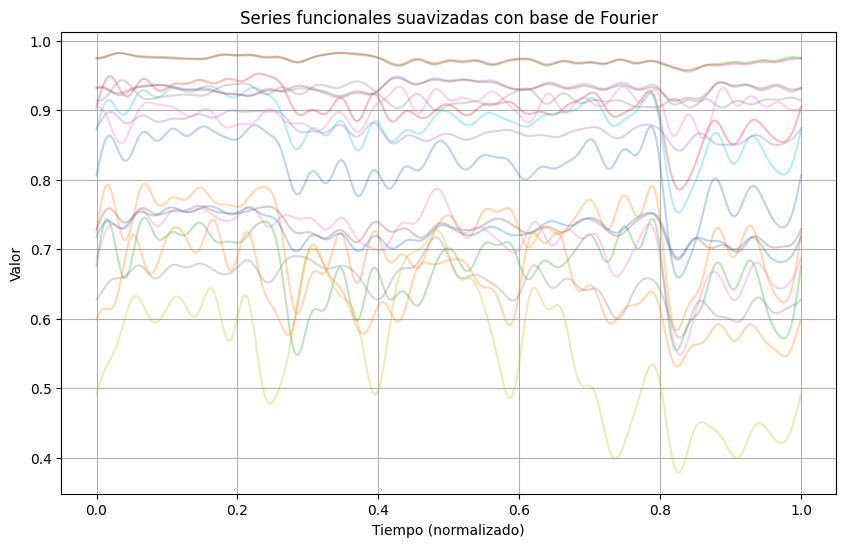

In [7]:
# TODAS LAS VARIABLES

# ---------------------------
# 1️⃣ Limpiar DataFrame
# ---------------------------
df_clean = (
    df_TS24_companded
    .interpolate(axis=0, limit_direction='both')
    .bfill()
    .ffill()
)

# ---------------------------
# 2️⃣ Quitar columna de tiempo (primera columna)
# ---------------------------
df_values = df_clean.iloc[:, 1:]   # todas excepto la primera
series_names = df_values.columns.tolist()

# ---------------------------
# 3️⃣ Crear base de Fourier
# ---------------------------
n_time = df_values.shape[0]       # número de puntos temporales
t = np.linspace(0, 1, n_time)     # dominio normalizado
n_basis = 50                     # ajustar según necesidad

basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

# ---------------------------
# 4️⃣ Convertir TODAS las columnas a representación funcional
# ---------------------------
fd = FDataGrid(
    data_matrix=df_values.T.values,  # cada fila = una serie
    grid_points=t
)

fd_basis = fd.to_basis(basis)

# ---------------------------
# 5️⃣ Evaluar funciones en la rejilla temporal
# ---------------------------
X_all = fd_basis(t).squeeze()   # shape: (n_series, n_time)

# ---------------------------
# 6️⃣ Plot opcional: todas las series suavizadas
# ---------------------------
plt.figure(figsize=(10, 6))

for serie in X_all:
    plt.plot(t, serie, alpha=0.3)

plt.xlabel("Tiempo (normalizado)")
plt.ylabel("Valor")
plt.title("Series funcionales suavizadas con base de Fourier")
plt.grid(True)
plt.show()

In [8]:
# SACAR CORRELACIONES
# Convertimos a DataFrame para calcular correlación
df_functional = pd.DataFrame(X_all.T, columns=series_names)

# =========================================================
# 5️⃣ MATRIZ DE CORRELACIÓN
# =========================================================

# Matriz de correlación (Pearson)
corr_matrix = df_functional.corr()

# Pasamos a formato largo
corr_unstack = corr_matrix.abs().unstack()

# Eliminamos autocorrelaciones
corr_unstack = corr_unstack[corr_unstack < 1]

# Convertimos a DataFrame
corr_df = corr_unstack.reset_index()
corr_df.columns = ['Var1', 'Var2', 'Correlation']

# Eliminamos duplicados espejo (A-B y B-A)
corr_df = corr_df[corr_df['Var1'] < corr_df['Var2']]

# Filtramos correlaciones mayores que 0.85
high_corr = corr_df[corr_df['Correlation'] > 0.85] \
    .sort_values(by='Correlation', ascending=False)

# =========================================================
# 6️⃣ RESULTADOS
# =========================================================
if high_corr.empty:
    print("No hay pares de variables funcionales con correlación mayor que 0.85")
else:
    print("Pares de variables funcionales con correlación > 0.85:")
    print(high_corr.to_string(index=False))

Pares de variables funcionales con correlación > 0.85:
                  Var1                    Var2  Correlation
             n_bytes_0             n_packets_0     0.993795
             n_flows_0         sum_n_dest_ip_0     0.985510
 tcp_udp_ratio_bytes_0 tcp_udp_ratio_packets_0     0.979164
     dir_ratio_bytes_0     dir_ratio_packets_0     0.974478
      sum_n_dest_asn_0         sum_n_dest_ip_0     0.950392
             n_flows_0        sum_n_dest_asn_0     0.948625
average_n_dest_ports_0      sum_n_dest_ports_0     0.934404
   average_n_dest_ip_0         sum_n_dest_ip_0     0.911661
average_n_dest_ports_0      std_n_dest_ports_0     0.907965
           n_packets_0         sum_n_dest_ip_0     0.905813
      std_n_dest_asn_0         sum_n_dest_ip_0     0.901199
      std_n_dest_asn_0        sum_n_dest_asn_0     0.897744
  average_n_dest_asn_0        std_n_dest_asn_0     0.896544
   average_n_dest_ip_0        std_n_dest_asn_0     0.893086
             n_flows_0             n_packets_

ANALISIS TOP 5 - COEF.CORRELACION

In [9]:
# TOP 5
# Top 5 correlaciones absolutas (sin autocorrelaciones ni duplicados)
top5_corr = corr_df.sort_values(by="Correlation", ascending=False).head(5)

print("Top 5 pares con mayor correlación:")
print(top5_corr.to_string(index=False))

Top 5 pares con mayor correlación:
                 Var1                    Var2  Correlation
            n_bytes_0             n_packets_0     0.993795
            n_flows_0         sum_n_dest_ip_0     0.985510
tcp_udp_ratio_bytes_0 tcp_udp_ratio_packets_0     0.979164
    dir_ratio_bytes_0     dir_ratio_packets_0     0.974478
     sum_n_dest_asn_0         sum_n_dest_ip_0     0.950392


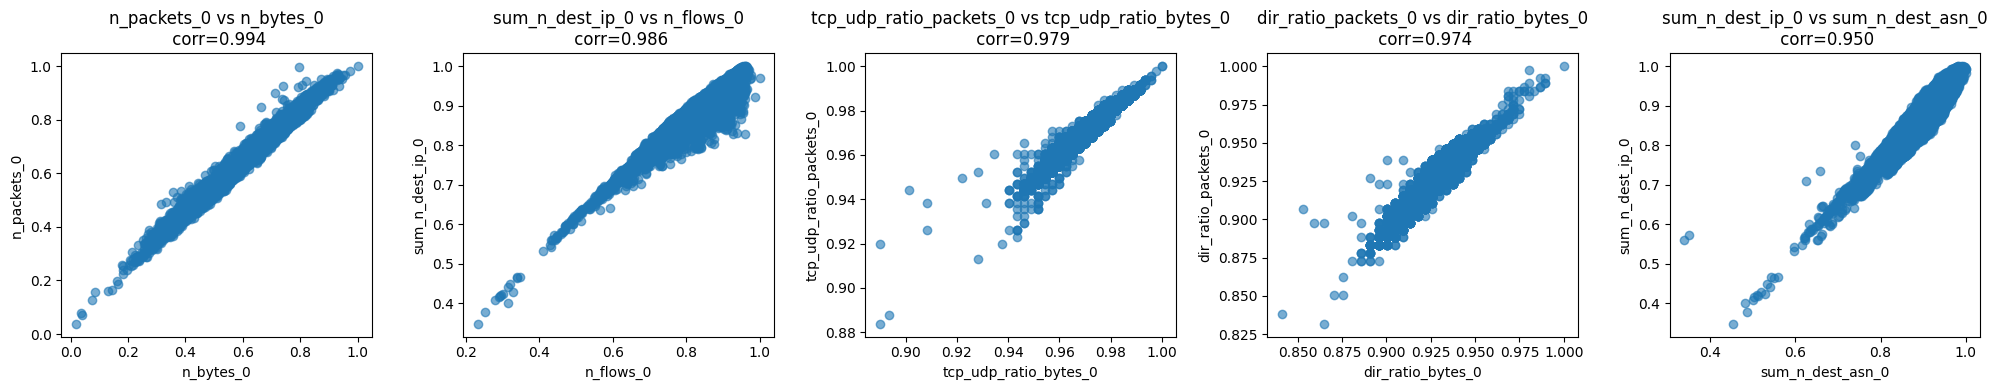

In [ ]:
import matplotlib.pyplot as plt

# Crear figura con subplots (5 gráficos)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (_, row) in enumerate(top5_corr.iterrows()):

    x_var = row["Var1"]
    y_var = row["Var2"]
    corr_value = row["Correlation"]

    axes[i].scatter(
        df_TS24_companded[x_var],
        df_TS24_companded[y_var],
        alpha=0.6
    )

    axes[i].set_xlabel(x_var)
    axes[i].set_ylabel(y_var)
    axes[i].set_title(f"{y_var} vs {x_var}\n corr={corr_value:.3f}")

plt.tight_layout()

# Guardar en PDF
# plt.savefig("scatter_plots_correlacion.pdf", format="pdf", bbox_inches="tight")

# Mostrar gráfico
plt.show()

In [11]:
# SEPARAR DF EN SEMANAS

# Extraer variables únicas del top5
cols_to_process = pd.unique(
    top5_corr[['Var1', 'Var2']].values.ravel()
).tolist()

# Extraer año ISO y semana ISO
iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week

weekly_data = {}

# Agrupar por año ISO y semana
for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):

    for col in cols_to_process:

        col_name = f"{col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[col].reset_index(drop=True)

df_weeks = pd.DataFrame(weekly_data)



In [12]:
# PASAR A SERIES FUNCIONALES

# ==========================================================
# 1️⃣ SEPARAR DF EN SEMANAS (como ya lo tienes)
# ==========================================================

iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week


weekly_data = {}

for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):
    for col in cols_to_process:
        col_name = f"{col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[col].reset_index(drop=True)

df_weeks = pd.DataFrame(weekly_data)

# ==========================================================
# 2️⃣ LIMPIAR DATAFRAME
# ==========================================================

df_weeks_clean = (
    df_weeks
    .interpolate(axis=0, limit_direction='both')
    .bfill()
    .ffill()
)

# ==========================================================
# 3️⃣ DEFINIR EJE TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)

minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60

days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7*24, 24)

# ==========================================================
# 4️⃣ PROCESAR CADA VARIABLE POR SEPARADO
# ==========================================================

n_basis = 50  # Ajustado con el codo del MSE

for col in cols_to_process:

    # Seleccionar semanas de esa variable
    col_weeks = [c for c in df_weeks_clean.columns if c.startswith(col)]
    df_var = df_weeks_clean[col_weeks]

    # Crear objeto funcional
    basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

    fd = FDataGrid(
        data_matrix=df_var.T.values,
        grid_points=t
    )

    fd_fourier = fd.to_basis(basis)

    # Evaluar en rejilla original
    X = fd_fourier(t).squeeze()



In [13]:
# SEMANAS DISPONIBLES
groups_week = dict(
    tuple(
        df_TS24_companded.groupby(
            [
                df_TS24_companded["time"].dt.isocalendar().year,
                df_TS24_companded["time"].dt.isocalendar().week,
            ]
        )
    )
)

# Semanas disponibles (AÑO, SEMANA)
semanas_disponibles = [(int(a), int(b)) for a, b in groups_week]
print(semanas_disponibles)

[(2023, 41), (2023, 42), (2023, 43), (2023, 44), (2023, 45), (2023, 46), (2023, 47), (2023, 48), (2023, 49), (2023, 50), (2023, 51), (2023, 52), (2024, 1), (2024, 2), (2024, 3), (2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12), (2024, 13), (2024, 14), (2024, 15), (2024, 16), (2024, 17), (2024, 18), (2024, 19), (2024, 20), (2024, 21), (2024, 22), (2024, 23), (2024, 24), (2024, 25), (2024, 26), (2024, 27), (2024, 28)]


In [15]:
# ELEGIR SEMANA
selected_week = "11_2024"    

Análisis: n_bytes_0 & n_packets_0


Anomalías detectadas: 56
PDF guardado: anomalias_correlacion_n_bytes_0_n_packets_0_semana_11_2024.pdf


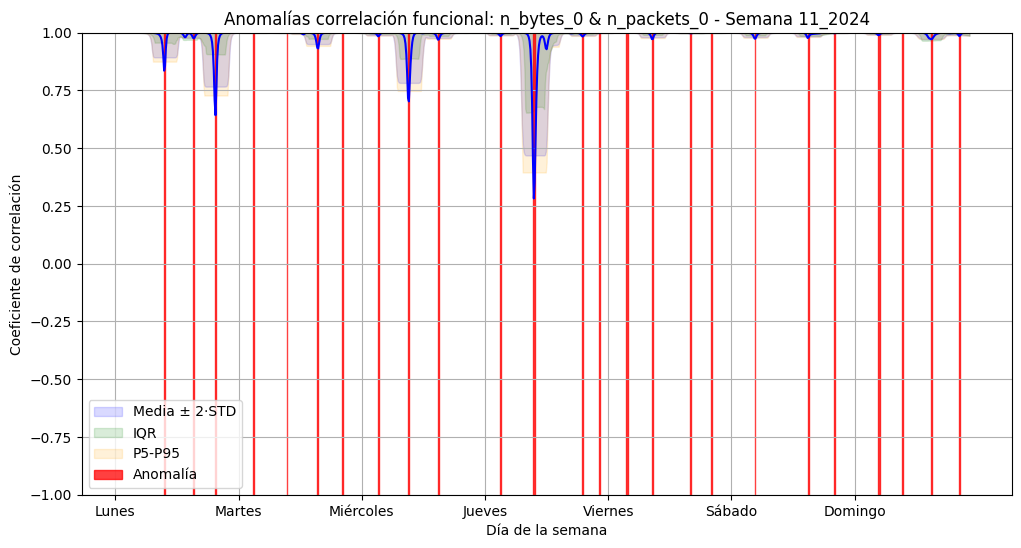

In [22]:
# ==========================================================
# CALCULO COEF.CORRELACION Y ANOMALIAS
# UMBRALES DINÁMICOS (MISMA REPRESENTACIÓN)
# ==========================================================

# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[0]
var2 = cols_to_process[1]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 20
step_size = 1

# ventana local para umbrales dinámicos
dynamic_window = 30

k = 2

percentil_low = 5
percentil_high = 95

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]

t = np.linspace(0, 1, n_time)

n_basis = 70

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"

    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

# ==========================================================
# 🔹 SERIES FUNCIONALES
# ==========================================================

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CORRELACIÓN DESLIZANTE FUNCIONAL
# ==========================================================

correlations = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:

        corr = np.nan

    else:

        corr = np.corrcoef(segment1, segment2)[0, 1]

    correlations.append(corr)

    time_centers.append(
        (start + window_size / 2) * 10 / 60
    )

corr_array = np.array(correlations)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS
# ==========================================================

upper_std_dyn = []
lower_std_dyn = []

upper_iqr_dyn = []
lower_iqr_dyn = []

upper_p95_dyn = []
lower_p5_dyn = []

anomalies_std = []
anomalies_iqr = []
anomalies_p95 = []

for i in range(len(corr_array)):

    # ------------------------------------------------------
    # Ventana local
    # ------------------------------------------------------

    start = max(0, i - dynamic_window // 2)

    end = min(
        len(corr_array),
        i + dynamic_window // 2
    )

    local_data = corr_array[start:end]

    # eliminar NaN
    local_data = local_data[~np.isnan(local_data)]

    # evitar problemas
    if len(local_data) < 5:

        upper_std_dyn.append(np.nan)
        lower_std_dyn.append(np.nan)

        upper_iqr_dyn.append(np.nan)
        lower_iqr_dyn.append(np.nan)

        upper_p95_dyn.append(np.nan)
        lower_p5_dyn.append(np.nan)

        anomalies_std.append(False)
        anomalies_iqr.append(False)
        anomalies_p95.append(False)

        continue

    # ======================================================
    # MEDIA ± STD LOCAL
    # ======================================================

    local_mean = np.mean(local_data)
    local_std = np.std(local_data)

    upper_std = local_mean + k * local_std
    lower_std = local_mean - k * local_std

    # ======================================================
    # IQR LOCAL
    # ======================================================

    Q1 = np.percentile(local_data, 25)
    Q3 = np.percentile(local_data, 75)

    IQR = Q3 - Q1

    upper_iqr = Q3 + 1.5 * IQR
    lower_iqr = Q1 - 1.5 * IQR

    # ======================================================
    # PERCENTILES LOCALES
    # ======================================================

    upper_p95 = np.percentile(
        local_data,
        percentil_high
    )

    lower_p5 = np.percentile(
        local_data,
        percentil_low
    )

    # ======================================================
    # GUARDAR UMBRALES
    # ======================================================

    upper_std_dyn.append(upper_std)
    lower_std_dyn.append(lower_std)

    upper_iqr_dyn.append(upper_iqr)
    lower_iqr_dyn.append(lower_iqr)

    upper_p95_dyn.append(upper_p95)
    lower_p5_dyn.append(lower_p5)

    # ======================================================
    # DETECCIÓN ANOMALÍAS
    # ======================================================

    value = corr_array[i]

    anomalies_std.append(
        (value > upper_std) or
        (value < lower_std)
    )

    anomalies_iqr.append(
        (value > upper_iqr) or
        (value < lower_iqr)
    )

    anomalies_p95.append(
        (value > upper_p95) or
        (value < lower_p5)
    )

# ==========================================================
# 🔹 CONSENSO FINAL
# ==========================================================

anomalies_decided = (
    np.array(anomalies_std).astype(int)
    + np.array(anomalies_iqr).astype(int)
    + np.array(anomalies_p95).astype(int)
) >= 2

print(
    "Anomalías detectadas:",
    np.sum(anomalies_decided)
)

# ==========================================================
# 🔹 REPRESENTACIÓN (MISMA ESTRUCTURA)
# ==========================================================

plt.figure(figsize=(12, 6))

# ==========================================================
# BANDAS DINÁMICAS
# ==========================================================

plt.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    alpha=0.15,
    color="blue",
    label=f"Media ± {k}·STD"
)

plt.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    alpha=0.15,
    color="green",
    label="IQR"
)

plt.fill_between(
    time_hours,
    lower_p5_dyn,
    upper_p95_dyn,
    alpha=0.15,
    color="orange",
    label=f"P{percentil_low}-P{percentil_high}"
)

# ==========================================================
# CURVA CORRELACIÓN
# ==========================================================

plt.plot(
    time_hours,
    corr_array,
    linewidth=1.5,
    color="blue"
)

# ==========================================================
# 🔹 DETECTAR BLOQUES CONSECUTIVOS
# ==========================================================

anomaly_blocks = []

start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:

        start_idx = i

    elif not is_anomaly and start_idx is not None:

        anomaly_blocks.append(
            (start_idx, i - 1)
        )

        start_idx = None

# si termina en anomalía
if start_idx is not None:

    anomaly_blocks.append(
        (start_idx, len(anomalies_decided) - 1)
    )

# ==========================================================
# 🔴 FRANJAS VERTICALES
# ==========================================================

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    plt.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.75,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# EJE X POR DÍAS
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.xticks(ticks, days)

# ==========================================================
# FORMATO
# ==========================================================

plt.xlabel("Día de la semana")

plt.ylabel(
    "Coeficiente de correlación"
)

plt.ylim(-1, 1)

plt.title(
    f"Anomalías correlación funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

plt.grid(True)

plt.legend()

# ==========================================================
# 🔹 GUARDAR FIGURA EN PDF
# ==========================================================

pdf_name = (
    f"anomalias_correlacion_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

plt.savefig(
    pdf_name,
    format="pdf",
    bbox_inches="tight"
)

print(f"PDF guardado: {pdf_name}")

plt.show()

Análisis: n_flows_0 & sum_n_dest_ip_0

Anomalías detectadas: 59
PDF guardado: anomalias_correlacion_n_flows_0_sum_n_dest_ip_0_semana_11_2024.pdf


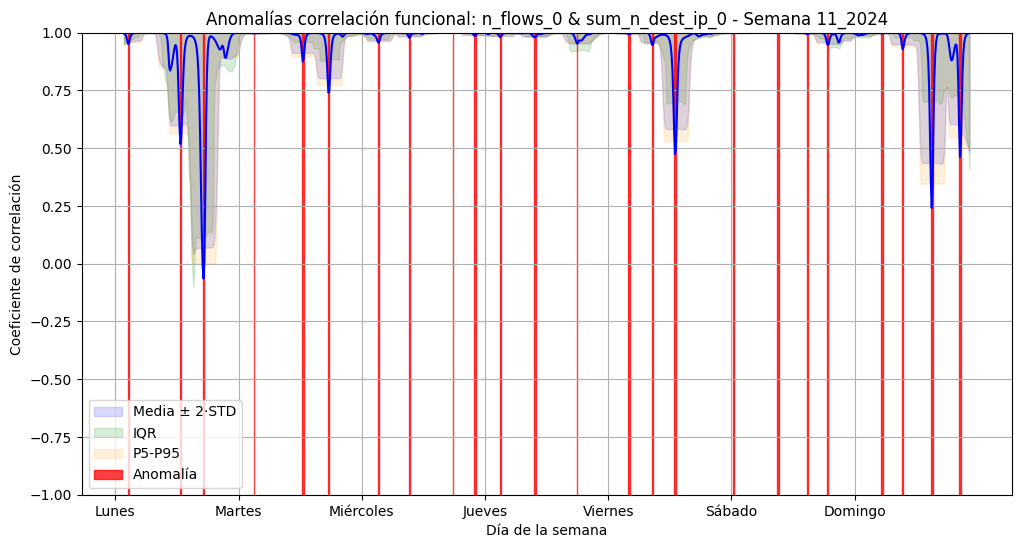

In [24]:
# CALCULO COEF.CORRELACION Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[2]
var2 = cols_to_process[3]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 20
step_size = 1

# ventana local para umbrales dinámicos
dynamic_window = 30

k = 2

percentil_low = 5
percentil_high = 95

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]

t = np.linspace(0, 1, n_time)

n_basis = 70

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"

    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

# ==========================================================
# 🔹 SERIES FUNCIONALES
# ==========================================================

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CORRELACIÓN DESLIZANTE FUNCIONAL
# ==========================================================

correlations = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:

        corr = np.nan

    else:

        corr = np.corrcoef(segment1, segment2)[0, 1]

    correlations.append(corr)

    time_centers.append(
        (start + window_size / 2) * 10 / 60
    )

corr_array = np.array(correlations)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS
# ==========================================================

upper_std_dyn = []
lower_std_dyn = []

upper_iqr_dyn = []
lower_iqr_dyn = []

upper_p95_dyn = []
lower_p5_dyn = []

anomalies_std = []
anomalies_iqr = []
anomalies_p95 = []

for i in range(len(corr_array)):

    # ------------------------------------------------------
    # Ventana local
    # ------------------------------------------------------

    start = max(0, i - dynamic_window // 2)

    end = min(
        len(corr_array),
        i + dynamic_window // 2
    )

    local_data = corr_array[start:end]

    # eliminar NaN
    local_data = local_data[~np.isnan(local_data)]

    # evitar problemas
    if len(local_data) < 5:

        upper_std_dyn.append(np.nan)
        lower_std_dyn.append(np.nan)

        upper_iqr_dyn.append(np.nan)
        lower_iqr_dyn.append(np.nan)

        upper_p95_dyn.append(np.nan)
        lower_p5_dyn.append(np.nan)

        anomalies_std.append(False)
        anomalies_iqr.append(False)
        anomalies_p95.append(False)

        continue

    # ======================================================
    # MEDIA ± STD LOCAL
    # ======================================================

    local_mean = np.mean(local_data)
    local_std = np.std(local_data)

    upper_std = local_mean + k * local_std
    lower_std = local_mean - k * local_std

    # ======================================================
    # IQR LOCAL
    # ======================================================

    Q1 = np.percentile(local_data, 25)
    Q3 = np.percentile(local_data, 75)

    IQR = Q3 - Q1

    upper_iqr = Q3 + 1.5 * IQR
    lower_iqr = Q1 - 1.5 * IQR

    # ======================================================
    # PERCENTILES LOCALES
    # ======================================================

    upper_p95 = np.percentile(
        local_data,
        percentil_high
    )

    lower_p5 = np.percentile(
        local_data,
        percentil_low
    )

    # ======================================================
    # GUARDAR UMBRALES
    # ======================================================

    upper_std_dyn.append(upper_std)
    lower_std_dyn.append(lower_std)

    upper_iqr_dyn.append(upper_iqr)
    lower_iqr_dyn.append(lower_iqr)

    upper_p95_dyn.append(upper_p95)
    lower_p5_dyn.append(lower_p5)

    # ======================================================
    # DETECCIÓN ANOMALÍAS
    # ======================================================

    value = corr_array[i]

    anomalies_std.append(
        (value > upper_std) or
        (value < lower_std)
    )

    anomalies_iqr.append(
        (value > upper_iqr) or
        (value < lower_iqr)
    )

    anomalies_p95.append(
        (value > upper_p95) or
        (value < lower_p5)
    )

# ==========================================================
# 🔹 CONSENSO FINAL
# ==========================================================

anomalies_decided = (
    np.array(anomalies_std).astype(int)
    + np.array(anomalies_iqr).astype(int)
    + np.array(anomalies_p95).astype(int)
) >= 2

print(
    "Anomalías detectadas:",
    np.sum(anomalies_decided)
)

# ==========================================================
# 🔹 REPRESENTACIÓN (MISMA ESTRUCTURA)
# ==========================================================

plt.figure(figsize=(12, 6))

# ==========================================================
# BANDAS DINÁMICAS
# ==========================================================

plt.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    alpha=0.15,
    color="blue",
    label=f"Media ± {k}·STD"
)

plt.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    alpha=0.15,
    color="green",
    label="IQR"
)

plt.fill_between(
    time_hours,
    lower_p5_dyn,
    upper_p95_dyn,
    alpha=0.15,
    color="orange",
    label=f"P{percentil_low}-P{percentil_high}"
)

# ==========================================================
# CURVA CORRELACIÓN
# ==========================================================

plt.plot(
    time_hours,
    corr_array,
    linewidth=1.5,
    color="blue"
)

# ==========================================================
# 🔹 DETECTAR BLOQUES CONSECUTIVOS
# ==========================================================

anomaly_blocks = []

start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:

        start_idx = i

    elif not is_anomaly and start_idx is not None:

        anomaly_blocks.append(
            (start_idx, i - 1)
        )

        start_idx = None

# si termina en anomalía
if start_idx is not None:

    anomaly_blocks.append(
        (start_idx, len(anomalies_decided) - 1)
    )

# ==========================================================
# 🔴 FRANJAS VERTICALES
# ==========================================================

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    plt.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.75,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# EJE X POR DÍAS
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.xticks(ticks, days)

# ==========================================================
# FORMATO
# ==========================================================

plt.xlabel("Día de la semana")

plt.ylabel(
    "Coeficiente de correlación"
)

plt.ylim(-1, 1)

plt.title(
    f"Anomalías correlación funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

plt.grid(True)

plt.legend()

# ==========================================================
# 🔹 GUARDAR FIGURA EN PDF
# ==========================================================

pdf_name = (
    f"anomalias_correlacion_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

plt.savefig(
    pdf_name,
    format="pdf",
    bbox_inches="tight"
)

print(f"PDF guardado: {pdf_name}")

plt.show()

Anaálisis: tcp_udp_ratio_bytes_0 & tcp_udp_ratio_packets_0

Anomalías detectadas: 61
PDF guardado: anomalias_correlacion_tcp_udp_ratio_bytes_0_tcp_udp_ratio_packets_0_semana_11_2024.pdf


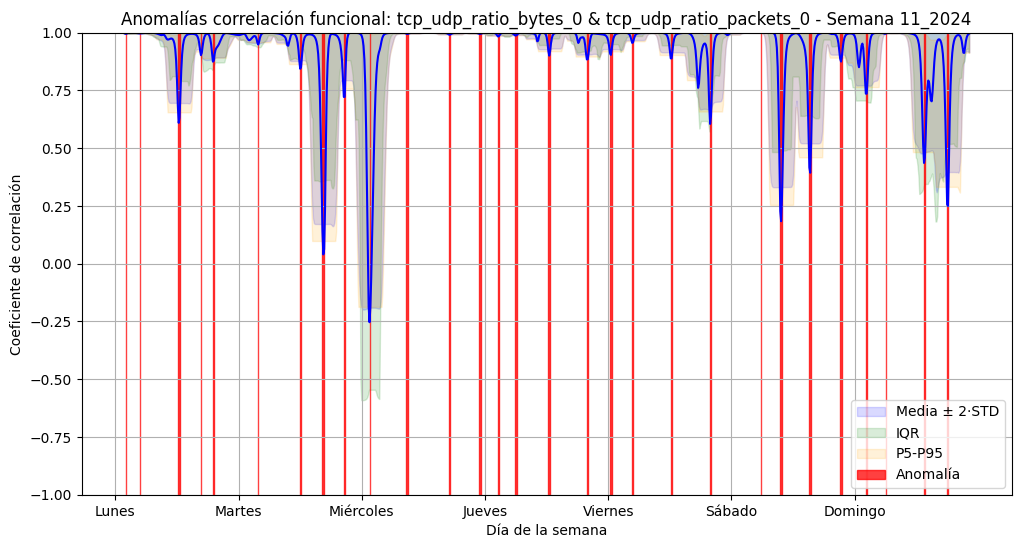

In [25]:
# CALCULO COEF.CORRELACION Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[4]
var2 = cols_to_process[5]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 20
step_size = 1

# ventana local para umbrales dinámicos
dynamic_window = 30

k = 2

percentil_low = 5
percentil_high = 95

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]

t = np.linspace(0, 1, n_time)

n_basis = 70

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"

    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

# ==========================================================
# 🔹 SERIES FUNCIONALES
# ==========================================================

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CORRELACIÓN DESLIZANTE FUNCIONAL
# ==========================================================

correlations = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:

        corr = np.nan

    else:

        corr = np.corrcoef(segment1, segment2)[0, 1]

    correlations.append(corr)

    time_centers.append(
        (start + window_size / 2) * 10 / 60
    )

corr_array = np.array(correlations)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS
# ==========================================================

upper_std_dyn = []
lower_std_dyn = []

upper_iqr_dyn = []
lower_iqr_dyn = []

upper_p95_dyn = []
lower_p5_dyn = []

anomalies_std = []
anomalies_iqr = []
anomalies_p95 = []

for i in range(len(corr_array)):

    # ------------------------------------------------------
    # Ventana local
    # ------------------------------------------------------

    start = max(0, i - dynamic_window // 2)

    end = min(
        len(corr_array),
        i + dynamic_window // 2
    )

    local_data = corr_array[start:end]

    # eliminar NaN
    local_data = local_data[~np.isnan(local_data)]

    # evitar problemas
    if len(local_data) < 5:

        upper_std_dyn.append(np.nan)
        lower_std_dyn.append(np.nan)

        upper_iqr_dyn.append(np.nan)
        lower_iqr_dyn.append(np.nan)

        upper_p95_dyn.append(np.nan)
        lower_p5_dyn.append(np.nan)

        anomalies_std.append(False)
        anomalies_iqr.append(False)
        anomalies_p95.append(False)

        continue

    # ======================================================
    # MEDIA ± STD LOCAL
    # ======================================================

    local_mean = np.mean(local_data)
    local_std = np.std(local_data)

    upper_std = local_mean + k * local_std
    lower_std = local_mean - k * local_std

    # ======================================================
    # IQR LOCAL
    # ======================================================

    Q1 = np.percentile(local_data, 25)
    Q3 = np.percentile(local_data, 75)

    IQR = Q3 - Q1

    upper_iqr = Q3 + 1.5 * IQR
    lower_iqr = Q1 - 1.5 * IQR

    # ======================================================
    # PERCENTILES LOCALES
    # ======================================================

    upper_p95 = np.percentile(
        local_data,
        percentil_high
    )

    lower_p5 = np.percentile(
        local_data,
        percentil_low
    )

    # ======================================================
    # GUARDAR UMBRALES
    # ======================================================

    upper_std_dyn.append(upper_std)
    lower_std_dyn.append(lower_std)

    upper_iqr_dyn.append(upper_iqr)
    lower_iqr_dyn.append(lower_iqr)

    upper_p95_dyn.append(upper_p95)
    lower_p5_dyn.append(lower_p5)

    # ======================================================
    # DETECCIÓN ANOMALÍAS
    # ======================================================

    value = corr_array[i]

    anomalies_std.append(
        (value > upper_std) or
        (value < lower_std)
    )

    anomalies_iqr.append(
        (value > upper_iqr) or
        (value < lower_iqr)
    )

    anomalies_p95.append(
        (value > upper_p95) or
        (value < lower_p5)
    )

# ==========================================================
# 🔹 CONSENSO FINAL
# ==========================================================

anomalies_decided = (
    np.array(anomalies_std).astype(int)
    + np.array(anomalies_iqr).astype(int)
    + np.array(anomalies_p95).astype(int)
) >= 2

print(
    "Anomalías detectadas:",
    np.sum(anomalies_decided)
)

# ==========================================================
# 🔹 REPRESENTACIÓN (MISMA ESTRUCTURA)
# ==========================================================

plt.figure(figsize=(12, 6))

# ==========================================================
# BANDAS DINÁMICAS
# ==========================================================

plt.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    alpha=0.15,
    color="blue",
    label=f"Media ± {k}·STD"
)

plt.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    alpha=0.15,
    color="green",
    label="IQR"
)

plt.fill_between(
    time_hours,
    lower_p5_dyn,
    upper_p95_dyn,
    alpha=0.15,
    color="orange",
    label=f"P{percentil_low}-P{percentil_high}"
)

# ==========================================================
# CURVA CORRELACIÓN
# ==========================================================

plt.plot(
    time_hours,
    corr_array,
    linewidth=1.5,
    color="blue"
)

# ==========================================================
# 🔹 DETECTAR BLOQUES CONSECUTIVOS
# ==========================================================

anomaly_blocks = []

start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:

        start_idx = i

    elif not is_anomaly and start_idx is not None:

        anomaly_blocks.append(
            (start_idx, i - 1)
        )

        start_idx = None

# si termina en anomalía
if start_idx is not None:

    anomaly_blocks.append(
        (start_idx, len(anomalies_decided) - 1)
    )

# ==========================================================
# 🔴 FRANJAS VERTICALES
# ==========================================================

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    plt.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.75,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# EJE X POR DÍAS
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.xticks(ticks, days)

# ==========================================================
# FORMATO
# ==========================================================

plt.xlabel("Día de la semana")

plt.ylabel(
    "Coeficiente de correlación"
)

plt.ylim(-1, 1)

plt.title(
    f"Anomalías correlación funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

plt.grid(True)

plt.legend()

# ==========================================================
# 🔹 GUARDAR FIGURA EN PDF
# ==========================================================

pdf_name = (
    f"anomalias_correlacion_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

plt.savefig(
    pdf_name,
    format="pdf",
    bbox_inches="tight"
)

print(f"PDF guardado: {pdf_name}")

plt.show()

Análisis: dir_ratio_bytes_0 & dir_ratio_packets_0

Anomalías detectadas: 52
PDF guardado: anomalias_correlacion_dir_ratio_bytes_0_dir_ratio_packets_0_semana_11_2024.pdf


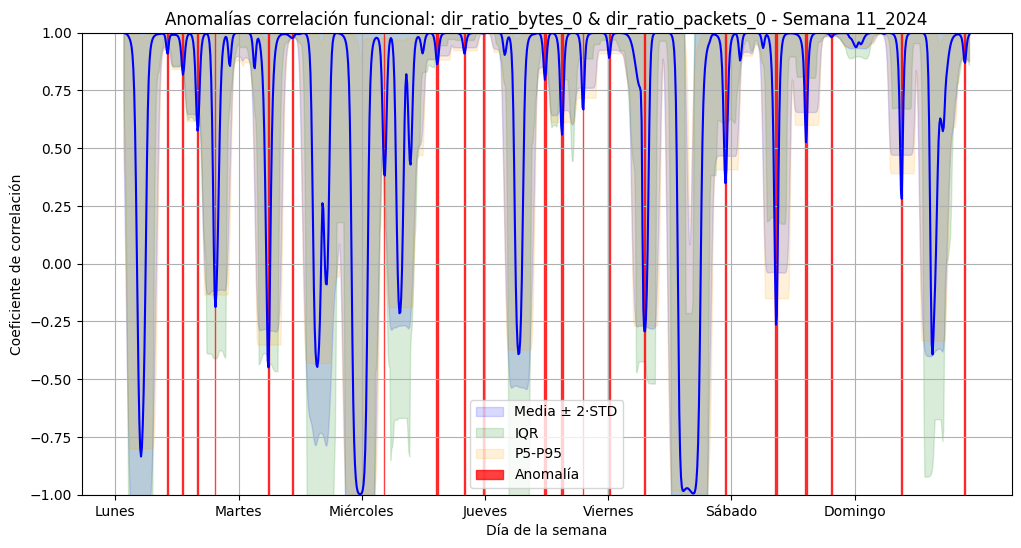

In [29]:
# CALCULO COEF.CORRELACION Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[6]
var2 = cols_to_process[7]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 20
step_size = 1

# ventana local para umbrales dinámicos
dynamic_window = 30

k = 2

percentil_low = 5
percentil_high = 95

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]

t = np.linspace(0, 1, n_time)

n_basis = 70

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"

    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

# ==========================================================
# 🔹 SERIES FUNCIONALES
# ==========================================================

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CORRELACIÓN DESLIZANTE FUNCIONAL
# ==========================================================

correlations = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:

        corr = np.nan

    else:

        corr = np.corrcoef(segment1, segment2)[0, 1]

    correlations.append(corr)

    time_centers.append(
        (start + window_size / 2) * 10 / 60
    )

corr_array = np.array(correlations)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS
# ==========================================================

upper_std_dyn = []
lower_std_dyn = []

upper_iqr_dyn = []
lower_iqr_dyn = []

upper_p95_dyn = []
lower_p5_dyn = []

anomalies_std = []
anomalies_iqr = []
anomalies_p95 = []

for i in range(len(corr_array)):

    # ------------------------------------------------------
    # Ventana local
    # ------------------------------------------------------

    start = max(0, i - dynamic_window // 2)

    end = min(
        len(corr_array),
        i + dynamic_window // 2
    )

    local_data = corr_array[start:end]

    # eliminar NaN
    local_data = local_data[~np.isnan(local_data)]

    # evitar problemas
    if len(local_data) < 5:

        upper_std_dyn.append(np.nan)
        lower_std_dyn.append(np.nan)

        upper_iqr_dyn.append(np.nan)
        lower_iqr_dyn.append(np.nan)

        upper_p95_dyn.append(np.nan)
        lower_p5_dyn.append(np.nan)

        anomalies_std.append(False)
        anomalies_iqr.append(False)
        anomalies_p95.append(False)

        continue

    # ======================================================
    # MEDIA ± STD LOCAL
    # ======================================================

    local_mean = np.mean(local_data)
    local_std = np.std(local_data)

    upper_std = local_mean + k * local_std
    lower_std = local_mean - k * local_std

    # ======================================================
    # IQR LOCAL
    # ======================================================

    Q1 = np.percentile(local_data, 25)
    Q3 = np.percentile(local_data, 75)

    IQR = Q3 - Q1

    upper_iqr = Q3 + 1.5 * IQR
    lower_iqr = Q1 - 1.5 * IQR

    # ======================================================
    # PERCENTILES LOCALES
    # ======================================================

    upper_p95 = np.percentile(
        local_data,
        percentil_high
    )

    lower_p5 = np.percentile(
        local_data,
        percentil_low
    )

    # ======================================================
    # GUARDAR UMBRALES
    # ======================================================

    upper_std_dyn.append(upper_std)
    lower_std_dyn.append(lower_std)

    upper_iqr_dyn.append(upper_iqr)
    lower_iqr_dyn.append(lower_iqr)

    upper_p95_dyn.append(upper_p95)
    lower_p5_dyn.append(lower_p5)

    # ======================================================
    # DETECCIÓN ANOMALÍAS
    # ======================================================

    value = corr_array[i]

    anomalies_std.append(
        (value > upper_std) or
        (value < lower_std)
    )

    anomalies_iqr.append(
        (value > upper_iqr) or
        (value < lower_iqr)
    )

    anomalies_p95.append(
        (value > upper_p95) or
        (value < lower_p5)
    )

# ==========================================================
# 🔹 CONSENSO FINAL
# ==========================================================

anomalies_decided = (
    np.array(anomalies_std).astype(int)
    + np.array(anomalies_iqr).astype(int)
    + np.array(anomalies_p95).astype(int)
) >= 2

print(
    "Anomalías detectadas:",
    np.sum(anomalies_decided)
)

# ==========================================================
# 🔹 REPRESENTACIÓN (MISMA ESTRUCTURA)
# ==========================================================

plt.figure(figsize=(12, 6))

# ==========================================================
# BANDAS DINÁMICAS
# ==========================================================

plt.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    alpha=0.15,
    color="blue",
    label=f"Media ± {k}·STD"
)

plt.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    alpha=0.15,
    color="green",
    label="IQR"
)

plt.fill_between(
    time_hours,
    lower_p5_dyn,
    upper_p95_dyn,
    alpha=0.15,
    color="orange",
    label=f"P{percentil_low}-P{percentil_high}"
)

# ==========================================================
# CURVA CORRELACIÓN
# ==========================================================

plt.plot(
    time_hours,
    corr_array,
    linewidth=1.5,
    color="blue"
)

# ==========================================================
# 🔹 DETECTAR BLOQUES CONSECUTIVOS
# ==========================================================

anomaly_blocks = []

start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:

        start_idx = i

    elif not is_anomaly and start_idx is not None:

        anomaly_blocks.append(
            (start_idx, i - 1)
        )

        start_idx = None

# si termina en anomalía
if start_idx is not None:

    anomaly_blocks.append(
        (start_idx, len(anomalies_decided) - 1)
    )

# ==========================================================
# 🔴 FRANJAS VERTICALES
# ==========================================================

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    plt.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.75,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# EJE X POR DÍAS
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.xticks(ticks, days)

# ==========================================================
# FORMATO
# ==========================================================

plt.xlabel("Día de la semana")

plt.ylabel(
    "Coeficiente de correlación"
)

plt.ylim(-1, 1)

plt.title(
    f"Anomalías correlación funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

plt.grid(True)

plt.legend()

# ==========================================================
# 🔹 GUARDAR FIGURA EN PDF
# ==========================================================

pdf_name = (
    f"anomalias_correlacion_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

plt.savefig(
    pdf_name,
    format="pdf",
    bbox_inches="tight"
)

print(f"PDF guardado: {pdf_name}")

plt.show()

Análisis: sum_n_dest_asn_0 & sum_n_dest_ip_0

Anomalías detectadas: 71
PDF guardado: anomalias_correlacion_sum_n_dest_asn_0_sum_n_dest_ip_0_semana_11_2024.pdf


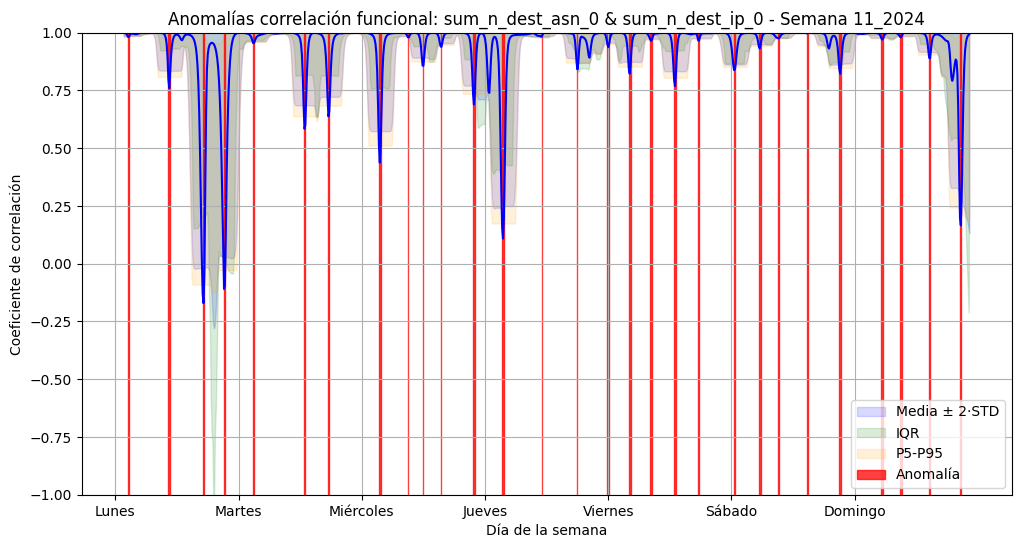

In [28]:
# CALCULO COEF.CORRELACION Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[8]
var2 = cols_to_process[3]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 20
step_size = 1

# ventana local para umbrales dinámicos
dynamic_window = 30

k = 2

percentil_low = 5
percentil_high = 95

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]

t = np.linspace(0, 1, n_time)

n_basis = 70

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"

    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

# ==========================================================
# 🔹 SERIES FUNCIONALES
# ==========================================================

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CORRELACIÓN DESLIZANTE FUNCIONAL
# ==========================================================

correlations = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:

        corr = np.nan

    else:

        corr = np.corrcoef(segment1, segment2)[0, 1]

    correlations.append(corr)

    time_centers.append(
        (start + window_size / 2) * 10 / 60
    )

corr_array = np.array(correlations)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS
# ==========================================================

upper_std_dyn = []
lower_std_dyn = []

upper_iqr_dyn = []
lower_iqr_dyn = []

upper_p95_dyn = []
lower_p5_dyn = []

anomalies_std = []
anomalies_iqr = []
anomalies_p95 = []

for i in range(len(corr_array)):

    # ------------------------------------------------------
    # Ventana local
    # ------------------------------------------------------

    start = max(0, i - dynamic_window // 2)

    end = min(
        len(corr_array),
        i + dynamic_window // 2
    )

    local_data = corr_array[start:end]

    # eliminar NaN
    local_data = local_data[~np.isnan(local_data)]

    # evitar problemas
    if len(local_data) < 5:

        upper_std_dyn.append(np.nan)
        lower_std_dyn.append(np.nan)

        upper_iqr_dyn.append(np.nan)
        lower_iqr_dyn.append(np.nan)

        upper_p95_dyn.append(np.nan)
        lower_p5_dyn.append(np.nan)

        anomalies_std.append(False)
        anomalies_iqr.append(False)
        anomalies_p95.append(False)

        continue

    # ======================================================
    # MEDIA ± STD LOCAL
    # ======================================================

    local_mean = np.mean(local_data)
    local_std = np.std(local_data)

    upper_std = local_mean + k * local_std
    lower_std = local_mean - k * local_std

    # ======================================================
    # IQR LOCAL
    # ======================================================

    Q1 = np.percentile(local_data, 25)
    Q3 = np.percentile(local_data, 75)

    IQR = Q3 - Q1

    upper_iqr = Q3 + 1.5 * IQR
    lower_iqr = Q1 - 1.5 * IQR

    # ======================================================
    # PERCENTILES LOCALES
    # ======================================================

    upper_p95 = np.percentile(
        local_data,
        percentil_high
    )

    lower_p5 = np.percentile(
        local_data,
        percentil_low
    )

    # ======================================================
    # GUARDAR UMBRALES
    # ======================================================

    upper_std_dyn.append(upper_std)
    lower_std_dyn.append(lower_std)

    upper_iqr_dyn.append(upper_iqr)
    lower_iqr_dyn.append(lower_iqr)

    upper_p95_dyn.append(upper_p95)
    lower_p5_dyn.append(lower_p5)

    # ======================================================
    # DETECCIÓN ANOMALÍAS
    # ======================================================

    value = corr_array[i]

    anomalies_std.append(
        (value > upper_std) or
        (value < lower_std)
    )

    anomalies_iqr.append(
        (value > upper_iqr) or
        (value < lower_iqr)
    )

    anomalies_p95.append(
        (value > upper_p95) or
        (value < lower_p5)
    )

# ==========================================================
# 🔹 CONSENSO FINAL
# ==========================================================

anomalies_decided = (
    np.array(anomalies_std).astype(int)
    + np.array(anomalies_iqr).astype(int)
    + np.array(anomalies_p95).astype(int)
) >= 2

print(
    "Anomalías detectadas:",
    np.sum(anomalies_decided)
)

# ==========================================================
# 🔹 REPRESENTACIÓN (MISMA ESTRUCTURA)
# ==========================================================

plt.figure(figsize=(12, 6))

# ==========================================================
# BANDAS DINÁMICAS
# ==========================================================

plt.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    alpha=0.15,
    color="blue",
    label=f"Media ± {k}·STD"
)

plt.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    alpha=0.15,
    color="green",
    label="IQR"
)

plt.fill_between(
    time_hours,
    lower_p5_dyn,
    upper_p95_dyn,
    alpha=0.15,
    color="orange",
    label=f"P{percentil_low}-P{percentil_high}"
)

# ==========================================================
# CURVA CORRELACIÓN
# ==========================================================

plt.plot(
    time_hours,
    corr_array,
    linewidth=1.5,
    color="blue"
)

# ==========================================================
# 🔹 DETECTAR BLOQUES CONSECUTIVOS
# ==========================================================

anomaly_blocks = []

start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:

        start_idx = i

    elif not is_anomaly and start_idx is not None:

        anomaly_blocks.append(
            (start_idx, i - 1)
        )

        start_idx = None

# si termina en anomalía
if start_idx is not None:

    anomaly_blocks.append(
        (start_idx, len(anomalies_decided) - 1)
    )

# ==========================================================
# 🔴 FRANJAS VERTICALES
# ==========================================================

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    plt.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.75,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# EJE X POR DÍAS
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.xticks(ticks, days)

# ==========================================================
# FORMATO
# ==========================================================

plt.xlabel("Día de la semana")

plt.ylabel(
    "Coeficiente de correlación"
)

plt.ylim(-1, 1)

plt.title(
    f"Anomalías correlación funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

plt.grid(True)

plt.legend()

# ==========================================================
# 🔹 GUARDAR FIGURA EN PDF
# ==========================================================

pdf_name = (
    f"anomalias_correlacion_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

plt.savefig(
    pdf_name,
    format="pdf",
    bbox_inches="tight"
)

print(f"PDF guardado: {pdf_name}")

plt.show()